In [1]:
# ============================================================
# CELDA 1 — Imports y carga de datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# Rutas
BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
REPORTS   = os.path.join(BASE, 'reports')
MODELS    = os.path.join(BASE, 'src', 'models')
RAW       = os.path.join(BASE, 'data', 'raw')

print("Imports correctos")

# Verificamos versión de Prophet
import prophet
print(f"Prophet version: {prophet.__version__}")

Imports correctos
Prophet version: 1.3.0


In [2]:
# ============================================================
# CELDA 2 — Carga y preparación datos de calendario
# ============================================================

# Cargamos los calendarios de las cuatro fuentes
def cargar_calendario(ruta, ciudad, fecha):
    df = pd.read_csv(ruta, compression='gzip', low_memory=False)
    df['ciudad'] = ciudad
    df['fecha_scrape'] = fecha
    return df

cal_mad_sep = cargar_calendario(
    os.path.join(RAW, 'madrid', 'sep2025', 'calendar.csv.gz'), 'madrid', 'sep2025')
cal_mad_jun = cargar_calendario(
    os.path.join(RAW, 'madrid', 'jun2025', 'calendar.csv.gz'), 'madrid', 'jun2025')
cal_bcn_sep = cargar_calendario(
    os.path.join(RAW, 'barcelona', 'sep2025', 'calendar.csv.gz'), 'barcelona', 'sep2025')
cal_bcn_jun = cargar_calendario(
    os.path.join(RAW, 'barcelona', 'jun2025', 'calendar.csv.gz'), 'barcelona', 'jun2025')

cal = pd.concat([cal_mad_sep, cal_mad_jun, cal_bcn_sep, cal_bcn_jun], ignore_index=True)

print(f"Calendario combinado: {len(cal):,} filas")
print(f"\nColumnas: {list(cal.columns)}")
print(f"\nMuestra:")
print(cal.head(3))

Calendario combinado: 28,005,018 filas

Columnas: ['listing_id', 'date', 'available', 'price', 'adjusted_price', 'minimum_nights', 'maximum_nights', 'ciudad', 'fecha_scrape']

Muestra:
   listing_id        date available  price  adjusted_price  minimum_nights  \
0       21853  2025-09-15         f    NaN             NaN               4   
1       21853  2025-09-16         f    NaN             NaN               4   
2       21853  2025-09-17         f    NaN             NaN               4   

   maximum_nights  ciudad fecha_scrape  
0              40  madrid      sep2025  
1              40  madrid      sep2025  
2              40  madrid      sep2025  


In [3]:
# ============================================================
# CELDA 3 — Agregación diaria para Prophet
# ============================================================

# Convertimos available a binario (t=disponible, f=ocupado)
cal['ocupado'] = (cal['available'] == 'f').astype(int)

# Convertimos fecha
cal['date'] = pd.to_datetime(cal['date'])

# Filtramos fechas razonables (2024 en adelante)
cal = cal[cal['date'] >= '2024-01-01']

# Agregamos: ocupación media diaria por ciudad
ocupacion_diaria = (cal.groupby(['ciudad', 'date'])['ocupado']
                    .mean()
                    .reset_index())
ocupacion_diaria.columns = ['ciudad', 'ds', 'y']

print(f"Series temporales generadas:")
for ciudad in ['madrid', 'barcelona']:
    datos = ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
    print(f"\n{ciudad.capitalize()}:")
    print(f"  Fechas: {datos['ds'].min().date()} → {datos['ds'].max().date()}")
    print(f"  Días:   {len(datos):,}")
    print(f"  Ocupación media: {datos['y'].mean():.1%}")

Series temporales generadas:

Madrid:
  Fechas: 2025-06-25 → 2026-09-14
  Días:   447
  Ocupación media: 54.6%

Barcelona:
  Fechas: 2025-06-23 → 2026-09-14
  Días:   449
  Ocupación media: 48.7%


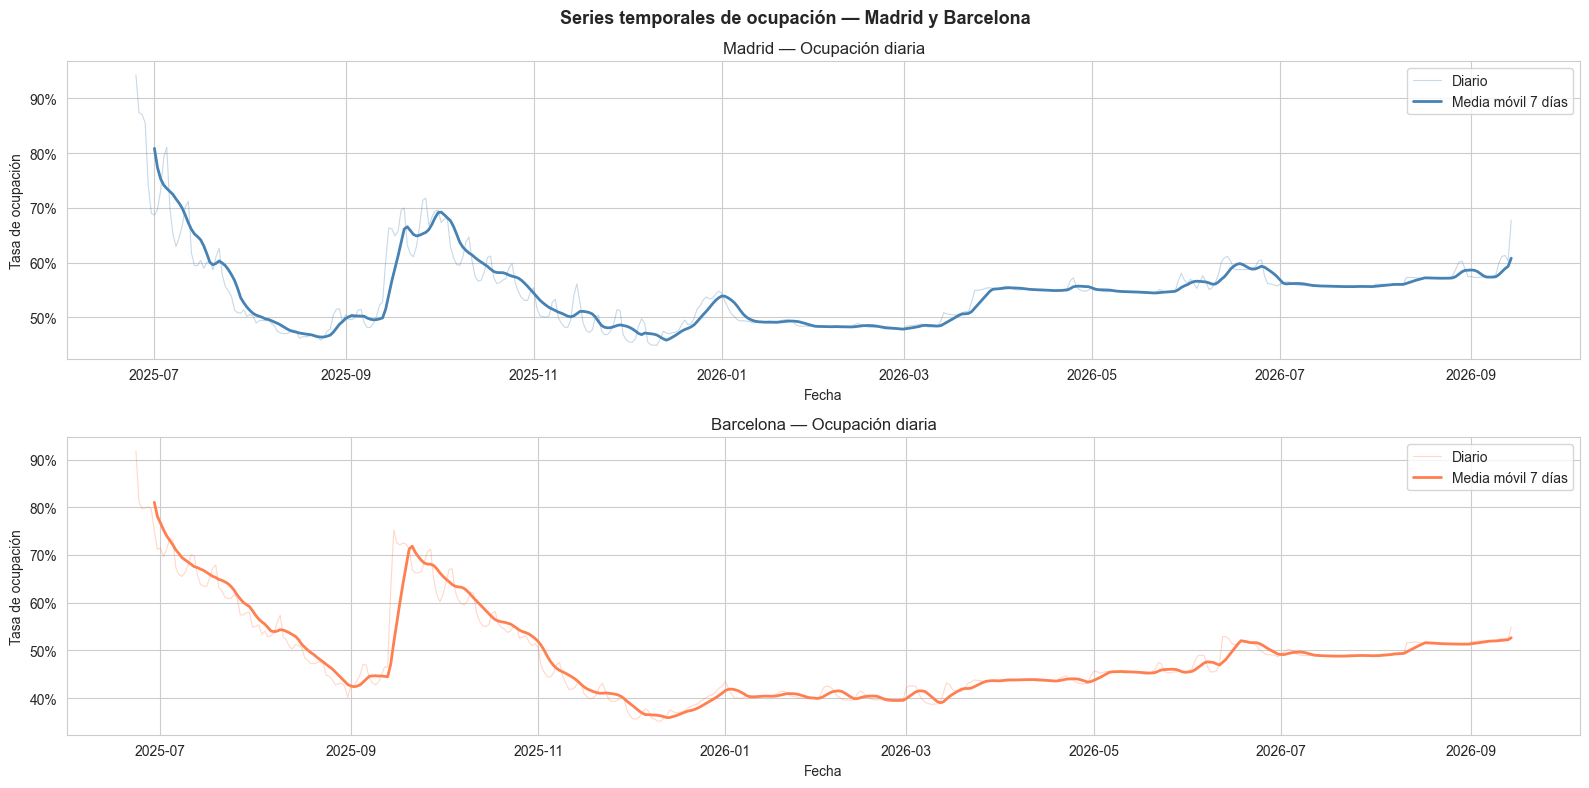

In [4]:
# ============================================================
# CELDA 4 — Visualización series temporales
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for ax, ciudad in zip(axes, ['madrid', 'barcelona']):
    datos = ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
    
    # Media móvil 7 días
    datos = datos.sort_values('ds').copy()
    datos['media_movil'] = datos['y'].rolling(7).mean()
    
    ax.plot(datos['ds'], datos['y'], alpha=0.3, 
            color='steelblue' if ciudad == 'madrid' else 'coral',
            linewidth=0.8, label='Diario')
    ax.plot(datos['ds'], datos['media_movil'],
            color='steelblue' if ciudad == 'madrid' else 'coral',
            linewidth=2, label='Media móvil 7 días')
    ax.set_title(f'{ciudad.capitalize()} — Ocupación diaria')
    ax.set_ylabel('Tasa de ocupación')
    ax.set_xlabel('Fecha')
    ax.legend()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Series temporales de ocupación — Madrid y Barcelona', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'series_temporales.png'), dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# CELDA 5 — Entrenamiento Prophet por ciudad
# ============================================================

modelos_prophet = {}
predicciones_prophet = {}

for ciudad in ['madrid', 'barcelona']:
    print(f"\n--- Entrenando Prophet para {ciudad.capitalize()} ---")
    
    datos = (ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad]
             .sort_values('ds')
             .reset_index(drop=True))
    
    # Dividimos: últimos 60 días para test
    train = datos[:-60]
    test  = datos[-60:]
    
    # Modelo Prophet con estacionalidad semanal y anual
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10,
    )
    
    # Añadimos festivos de España
    modelo.add_country_holidays(country_name='ES')
    
    modelo.fit(train)
    
    # Predicción 12 meses hacia adelante
    futuro = modelo.make_future_dataframe(periods=365)
    forecast = modelo.predict(futuro)
    
    # Métricas sobre test
    pred_test = forecast[forecast['ds'].isin(test['ds'])]['yhat'].values
    mae = mean_absolute_error(test['y'].values, pred_test)
    
    print(f"  MAE test (60 días): {mae:.4f} ({mae*100:.1f} puntos porcentuales)")
    
    modelos_prophet[ciudad]      = modelo
    predicciones_prophet[ciudad] = forecast

print("\n✅ Modelos Prophet entrenados")

20:11:20 - cmdstanpy - INFO - Chain [1] start processing



--- Entrenando Prophet para Madrid ---


20:11:22 - cmdstanpy - INFO - Chain [1] done processing
20:11:22 - cmdstanpy - INFO - Chain [1] start processing
20:11:22 - cmdstanpy - INFO - Chain [1] done processing


  MAE test (60 días): 0.1141 (11.4 puntos porcentuales)

--- Entrenando Prophet para Barcelona ---
  MAE test (60 días): 0.1212 (12.1 puntos porcentuales)

✅ Modelos Prophet entrenados


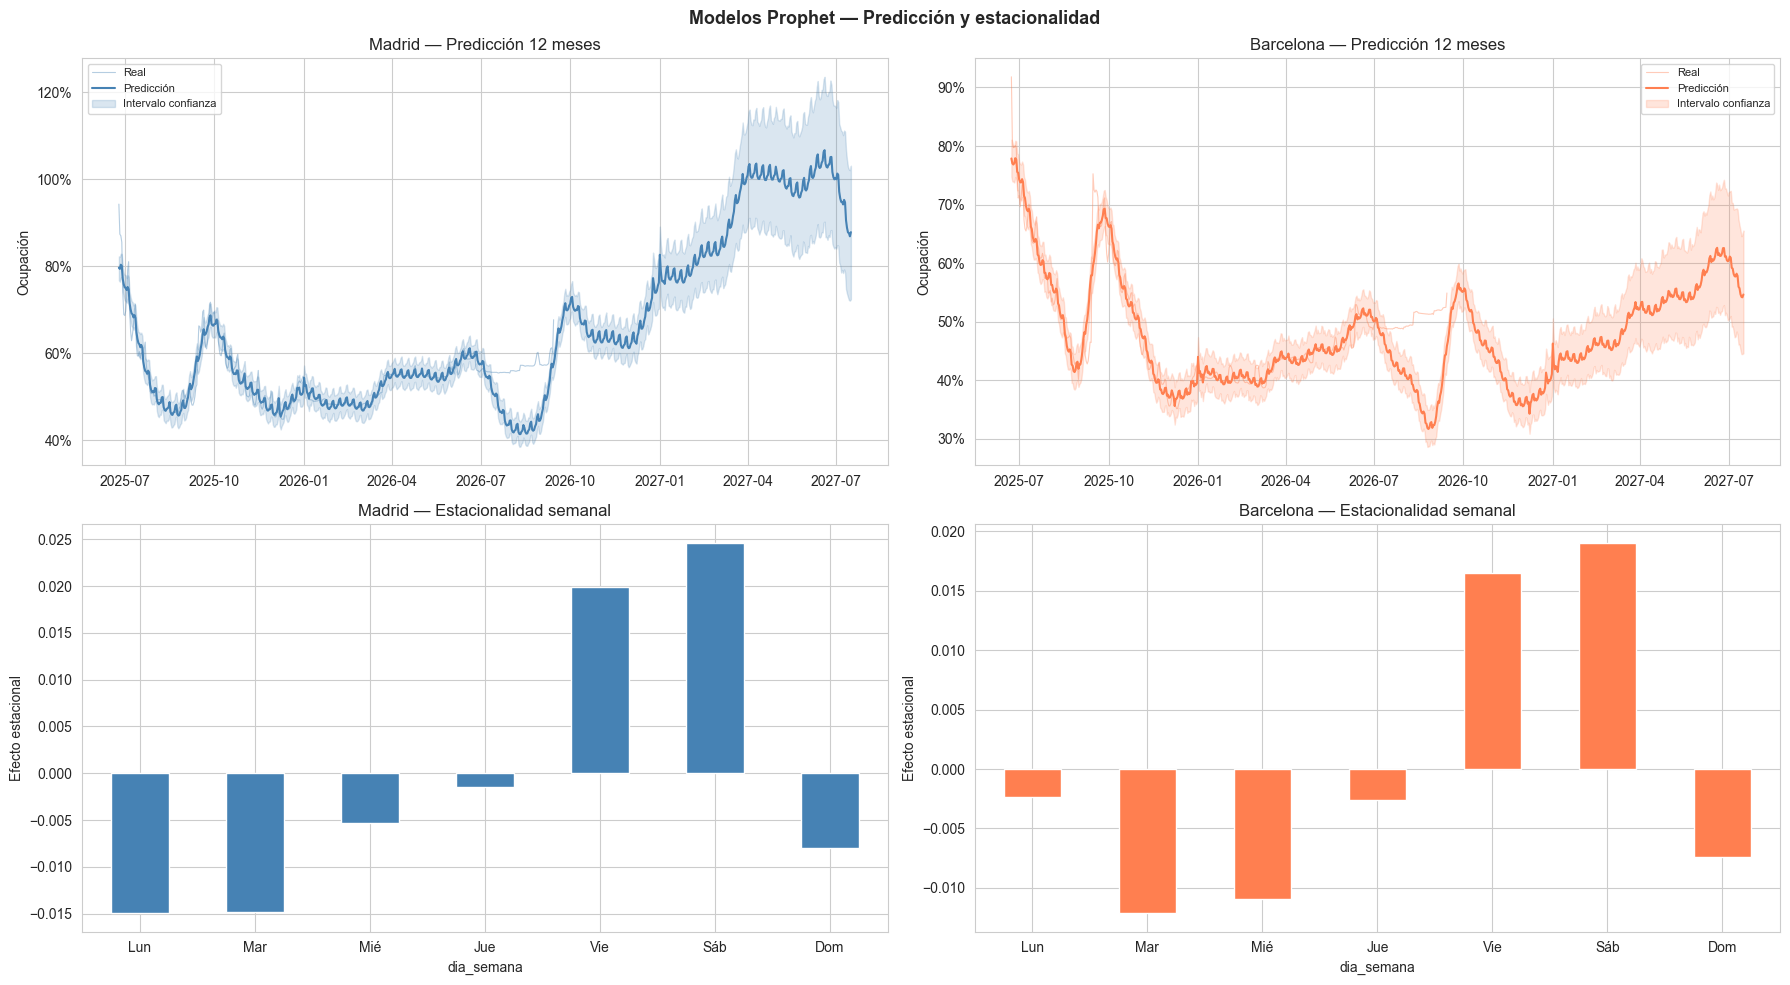

In [7]:
# ============================================================
# CELDA 6 — Visualización predicciones Prophet
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for idx, ciudad in enumerate(['madrid', 'barcelona']):
    datos    = ocupacion_diaria[ocupacion_diaria['ciudad'] == ciudad].sort_values('ds')
    forecast = predicciones_prophet[ciudad]
    modelo   = modelos_prophet[ciudad]
    color    = 'steelblue' if ciudad == 'madrid' else 'coral'

    # Predicción completa
    ax = axes[0][idx]
    ax.plot(datos['ds'], datos['y'], alpha=0.4, color=color,
            linewidth=0.8, label='Real')
    ax.plot(forecast['ds'], forecast['yhat'], color=color,
            linewidth=1.5, label='Predicción')
    ax.fill_between(forecast['ds'],
                    forecast['yhat_lower'],
                    forecast['yhat_upper'],
                    alpha=0.2, color=color, label='Intervalo confianza')
    ax.set_title(f'{ciudad.capitalize()} — Predicción 12 meses')
    ax.set_ylabel('Ocupación')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

    # Estacionalidad semanal
    ax = axes[1][idx]
    weekly = forecast[['ds', 'weekly']].copy()
    weekly['dia_semana'] = pd.to_datetime(weekly['ds']).dt.day_name()
    weekly_mean = weekly.groupby('dia_semana')['weekly'].mean()
    orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
    weekly_mean = weekly_mean.reindex(orden)
    weekly_mean.plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{ciudad.capitalize()} — Estacionalidad semanal')
    ax.set_ylabel('Efecto estacional')
    ax.set_xticklabels(['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'], rotation=0)

plt.suptitle('Modelos Prophet — Predicción y estacionalidad', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'prophet_predicciones.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# CELDA 7 — Guardado modelos Prophet
# ============================================================

for ciudad in ['madrid', 'barcelona']:
    # Guardamos modelo
    ruta_modelo = os.path.join(MODELS, f'prophet_{ciudad}.pkl')
    with open(ruta_modelo, 'wb') as f:
        pickle.dump(modelos_prophet[ciudad], f)
    
    # Guardamos predicción
    ruta_forecast = os.path.join(MODELS, f'prophet_forecast_{ciudad}.pkl')
    with open(ruta_forecast, 'wb') as f:
        pickle.dump(predicciones_prophet[ciudad], f)
    
    tam = os.path.getsize(ruta_modelo) / (1024)
    print(f"✅ {ciudad}: modelo guardado ({tam:.0f} KB)")

# Guardamos métricas
metricas_prophet = {
    'madrid':    {'mae': 0.1141},
    'barcelona': {'mae': 0.1212}
}
ruta_metricas = os.path.join(MODELS, 'metricas_prophet.pkl')
with open(ruta_metricas, 'wb') as f:
    pickle.dump(metricas_prophet, f)

print("\n✅ Todos los modelos Prophet guardados")

✅ madrid: modelo guardado (54 KB)
✅ barcelona: modelo guardado (55 KB)

✅ Todos los modelos Prophet guardados
